<h3><center>Convolutional Neural Network</center></h3>
<h6><center>very closely resembling a</center></h6>
<h3><center>Wave Net</center></h3>

In [97]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [98]:
# reading words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))

32033
15


In [ ]:
# Encoding and decoding
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {s:i for i, s in stoi.items()}
vocab_size = len(itos)
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [100]:
# Shuffling words
import random
random.seed(42)
random.shuffle(words)

In [101]:
# Build dataset
block_size = 8

def build_dataset(words):

    X, Y = [], []

    for word in words:
        context = [0] * block_size
        for ch in word + '.': 
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print(X.shape, Y.shape)
    return X, Y


n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [102]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [112]:
# Liner, BatchNorm for experiment optimization

class Linear:

    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = (torch.randn(fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])    

# -----------------------------------------------------------------------------------------------

class BatchNorm:

    def __init__(self, dim, eps = 1e-5, momentum = 0.1):

        self.dim = dim
        self.eps = eps
        self.momentum = momentum
        self.traning = True

        # Parameters (changes with traning)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Buffers (changes with momentum)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        
        # Calculates forward pass
        if self.traning:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            x_mean = x.mean(dim,keepdim=True)
            x_var = x.var(dim, keepdim=True)
        else:
            x_mean = self.running_mean
            x_var = self.running_var

        xhat = (x-x_mean) / torch.sqrt(x_var + self.eps)
        self.out = self.gamma * xhat + self.beta

        # Update the buffers
        if self.traning:
            with torch.no_grad():
                self.running_mean = ((1 - self.momentum) * self.running_mean) + (self.momentum * x_mean)
                self.running_var = ((1-self.momentum) * self.running_var) + (self.momentum * x_var)
        return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]
        
# -----------------------------------------------------------------------------------------------

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return[]
    
# -----------------------------------------------------------------------------------------------

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
# -----------------------------------------------------------------------------------------------

class FlattenCons:

    def __init__(self, n):
        self.n = n
        
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n , C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
# -----------------------------------------------------------------------------------------------

class Sequential:

    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [104]:
# Manually setting seed

torch.manual_seed(42)

In [105]:
# Building the nn layers

n_embed = 10
n_hidden = 200
group_size = 2


model = Sequential([
    Embedding(vocab_size, n_embed),
    FlattenCons(group_size), Linear(n_embed * group_size, n_hidden, bias = False), BatchNorm(n_hidden), Tanh(),
    FlattenCons(group_size), Linear(group_size * n_hidden, n_hidden, bias = False), BatchNorm(n_hidden), Tanh(),
    FlattenCons(group_size), Linear(n_hidden * group_size, n_hidden, bias = False), BatchNorm(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# Parameter initialization
with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()

print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

170897


In [114]:
# Batch norm and forward pass

epochs = 200000
batch_size = 32
lossi = []

for i in range(epochs):

    # Minbatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb.long())

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Keep track
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{epochs:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 1.9456
  10000/ 200000: 2.2175
  20000/ 200000: 2.0810
  30000/ 200000: 1.8402
  40000/ 200000: 1.4756
  50000/ 200000: 1.8771
  60000/ 200000: 1.7365
  70000/ 200000: 1.6740
  80000/ 200000: 1.5420
  90000/ 200000: 1.7682
 100000/ 200000: 1.9140
 110000/ 200000: 1.3335
 120000/ 200000: 1.6464
 130000/ 200000: 1.8577
 140000/ 200000: 1.8058
 150000/ 200000: 1.7680
 160000/ 200000: 1.7495
 170000/ 200000: 1.5466
 180000/ 200000: 1.4605
 190000/ 200000: 1.6875


In [113]:
# plt.plot(lossi)
# plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (1, 8, 10)
FlattenCons : (1, 4, 20)
Linear : (1, 4, 200)
BatchNorm : (1, 4, 200)
Tanh : (1, 4, 200)
FlattenCons : (1, 2, 400)
Linear : (1, 2, 200)
BatchNorm : (1, 2, 200)
Tanh : (1, 2, 200)
FlattenCons : (1, 400)
Linear : (1, 200)
BatchNorm : (1, 200)
Tanh : (1, 200)
Linear : (1, 27)


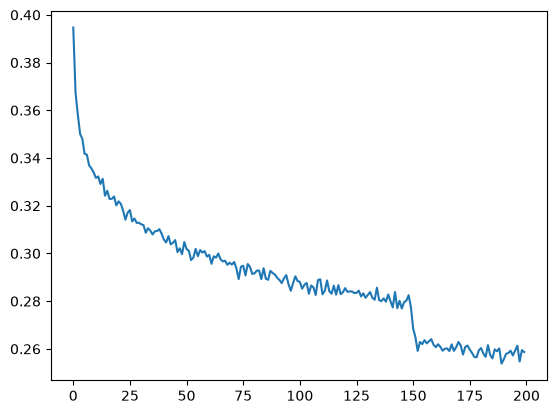

In [111]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [108]:
# Switching to eval mode
for layer in model.layers:
    layer.traning = False

In [109]:
# Evaluation of the loss

@torch.no_grad()
def split_loss(split):
    x, y = {
        'train' : (Xtr, Ytr),
        'val' : (Xdev, Ydev),
        'test' : (Xte, Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 1.7768319845199585
val 1.9831289052963257
test 1.9803582429885864


In [110]:
# Sampling from the model

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        # emb = C[torch.tensor([context])]
        # x = emb.view(emb.shape[0], -1)
        # for layer in layers:
        #     x = layer(x)
        # logits = x

        logits = model(torch.tensor([context]))

        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

aleah.
ameiya.
aryef.
malayna.
thirell.
arlomese.
imeya.
jukaya.
aliviana.
orianna.
ahbo.
rugustian.
samondold.
adelly.
jaaryaross.
keliena.
tannell.
isey.
quinn.
kreslia.
